# Information asymétrique : antisélection et marché des lemons

Ce notebook étudie l’**antisélection**, c’est-à-dire l’information privée détenue avant l’échange ou la signature d’un contrat. Il prépare deux extensions distinctes : le **signaling**, où l’agent informé choisit un signal coûteux, et le **screening**, où le côté non informé propose un dispositif d’auto-sélection. L’aléa moral, qui concerne une action privée après contrat, reste hors du modèle principal.

Le cadre commun est celui de Harsanyi : un type privé est tiré selon un prior commun, puis la stratégie de l’agent informé peut dépendre de ce type. Cette première tranche implémente le modèle price-only d’Akerlof ; elle n’y ajoute ni menu, ni signal, ni condition de single-crossing.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from itertools import combinations
from math import exp, isclose

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
print("Environnement prêt : NumPy, pandas, Matplotlib et outils de menus finis chargés")

Environnement prêt : NumPy, pandas, Matplotlib et outils de menus finis chargés


## Akerlof : un point fixe de participation à prix unique

Le vendeur observe la qualité $q\in\{L,H\}$. À un prix candidat $P$, les vendeurs participants forment

$$S(P)=\{q\mid c_q\le P\}.$$

Lorsque cet ensemble est non vide, l’acheteur accepte si

$$P\le \mathbb E[v(q)\mid q\in S(P)].$$

Le prix doit donc être compatible simultanément avec la participation des vendeurs et la disposition à payer de l’acheteur. Pour faire participer les deux qualités, il faut $P\ge c_H$ et $P\le \pi v_H+(1-\pi)v_L$. Si $v_H>v_L$, le pooling devient donc possible lorsque

$$\pi\ge\pi_{min}=\frac{c_H-v_L}{v_H-v_L}.$$

Ce seuil vaut uniquement pour le modèle fini défini ici.

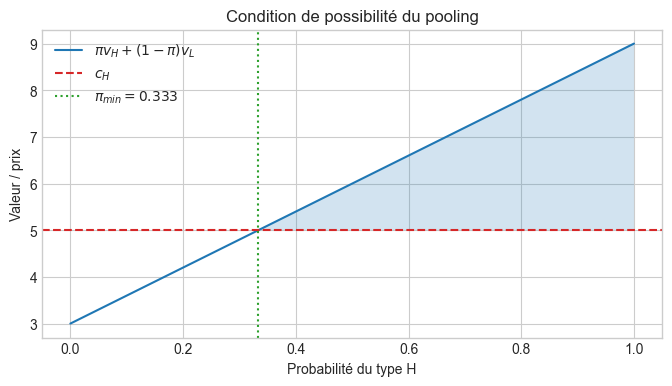

,scenario,pi,regime,participants,price_lower,price_upper,upper_closed,conditional_value
0,faible part de H,0.200000,lemons_only,"(L,)",1.0,3.0,True,3.0
1,seuil exact,0.333333,lemons_only,"(L,)",1.0,3.0,True,3.0
2,seuil exact,0.333333,pooling,"(L, H)",5.0,5.0,True,5.0
3,forte part de H,0.500000,lemons_only,"(L,)",1.0,3.0,True,3.0
4,forte part de H,0.500000,pooling,"(L, H)",5.0,6.0,True,6.0
5,aucun échange,0.500000,no_trade,(),NaN,NaN,NaN,NaN


In [2]:
def akerlof_equilibria(
    pi: float,
    c_low: float,
    c_high: float,
    v_low: float,
    v_high: float,
) -> list[dict[str, object]]:
    """Énumère tous les intervalles de prix compatibles avec le point fixe."""
    if not 0.0 <= pi <= 1.0:
        raise ValueError("pi doit appartenir à [0, 1]")
    if not c_low < c_high:
        raise ValueError("Le modèle suppose c_low < c_high")
    if not v_low < v_high:
        raise ValueError("Le modèle suppose v_low < v_high")

    equilibria: list[dict[str, object]] = []
    lemons_upper = min(c_high, v_low)
    if c_low <= lemons_upper:
        equilibria.append({
            "regime": "lemons_only",
            "participants": ("L",),
            "price_lower": c_low,
            "price_upper": lemons_upper,
            "upper_closed": v_low < c_high,
            "conditional_value": v_low,
        })

    pooling_value = pi * v_high + (1.0 - pi) * v_low
    if c_high <= pooling_value:
        equilibria.append({
            "regime": "pooling",
            "participants": ("L", "H"),
            "price_lower": c_high,
            "price_upper": pooling_value,
            "upper_closed": True,
            "conditional_value": pooling_value,
        })

    if not equilibria:
        return [{"regime": "no_trade", "participants": ()}]
    return equilibria


scenarios = [
    {"scenario": "faible part de H", "pi": 0.20, "c_low": 1, "c_high": 5, "v_low": 3, "v_high": 9},
    {"scenario": "seuil exact", "pi": 1 / 3, "c_low": 1, "c_high": 5, "v_low": 3, "v_high": 9},
    {"scenario": "forte part de H", "pi": 0.50, "c_low": 1, "c_high": 5, "v_low": 3, "v_high": 9},
    {"scenario": "aucun échange", "pi": 0.50, "c_low": 4, "c_high": 7, "v_low": 3, "v_high": 6},
]
rows = []
for scenario in scenarios:
    parameters = {key: value for key, value in scenario.items() if key != "scenario"}
    for equilibrium in akerlof_equilibria(**parameters):
        rows.append({"scenario": scenario["scenario"], "pi": scenario["pi"], **equilibrium})
akerlof_results = pd.DataFrame(rows)

pi_values = np.linspace(0, 1, 201)
pooling_values = pi_values * 9 + (1 - pi_values) * 3
pi_min = (5 - 3) / (9 - 3)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(pi_values, pooling_values, label=r"$\pi v_H+(1-\pi)v_L$")
ax.axhline(5, color="tab:red", linestyle="--", label=r"$c_H$")
ax.axvline(pi_min, color="tab:green", linestyle=":", label=fr"$\pi_{{min}}={pi_min:.3f}$")
ax.fill_between(pi_values, 5, pooling_values, where=pooling_values >= 5, alpha=0.2)
ax.set(
    xlabel="Probabilité du type H",
    ylabel="Valeur / prix",
    title="Condition de possibilité du pooling",
)
ax.legend()
plt.show()
akerlof_results

### Lecture du résultat

Au-dessus du seuil $\pi_{min}=(c_H-v_L)/(v_H-v_L)=1/3$, un intervalle pooling devient compatible. Il ne fait pas disparaître automatiquement l’intervalle lemons-only : plusieurs équilibres peuvent coexister. Au seuil exact, le pooling est un singleton $P=c_H$. Cette multiplicité est un résultat du point fixe, pas une erreur de classification.

## Exercice 1 — classer les régimes

À partir du tableau précédent, compléter la fonction pour associer à chaque scénario l’ensemble de ses régimes. Vérifier en particulier que le scénario au seuil admet deux régimes, tandis que le dernier conduit à `no_trade`.

**Indice :** grouper les lignes par `scenario`, puis convertir la colonne `regime` en ensemble.

In [3]:
def exercice_classer_regimes() -> dict[str, set[str]] | None:
    # TODO étudiant : grouper akerlof_results par scénario et collecter les régimes.
    return None


print("Classification à compléter :", exercice_classer_regimes())

Classification à compléter : None


## Exercice 2 — retrouver le seuil graphiquement

Compléter la fonction pour retourner le premier prior de la grille `pi_values` tel que la valeur du pooling atteint `c_high = 5`. Comparer ce résultat numérique à la formule analytique de $\pi_{min}$.

**Indice :** utiliser un masque booléen sur `pooling_values`, puis sélectionner son premier indice vrai.

In [4]:
def exercice_seuil_numerique() -> float | None:
    # TODO étudiant : trouver le premier pi tel que pooling_values >= 5.
    return None


print("Seuil numérique à compléter :", exercice_seuil_numerique())

Seuil numérique à compléter : None


## Exercice 3 — frontière d’Akerlof

Compléter la fonction suivante pour détecter si l’intervalle pooling se réduit à un prix unique au seuil $\pi_{min}$. Vérifier ensuite que `lemons_only` et `pooling` peuvent tous deux apparaître dans la liste retournée.

**Étape 1 :** appeler `akerlof_equilibria` au seuil.  
**Étape 2 :** isoler le régime `pooling`.  
**Étape 3 :** comparer ses bornes inférieure et supérieure.

In [5]:
def exercice_pooling_singleton() -> bool | None:
    # TODO étudiant : appeler akerlof_equilibria au seuil et comparer les bornes.
    return None


print("Résultat à compléter :", exercice_pooling_singleton())


Résultat à compléter : None


## Spence : signal coûteux et contraintes d’incitation

Deux types de productivité $y_H>y_L$ choisissent un signal $s$. En séparation concurrentielle, $w(s_q)=y_q$ et l’utilité du candidat est

$$u(q,s)=w(s)-c(q,s).$$

Pour une paire séparatrice $(s_L,s_H)$, les quatre contraintes sont :

| Contrainte | Inégalité |
|---|---|
| $IC_H$ | $y_H-c(H,s_H)\ge y_L-c(H,s_L)$ |
| $IC_L$ | $y_L-c(L,s_L)\ge y_H-c(L,s_H)$ |
| $IR_H$ | $y_H-c(H,s_H)\ge \bar u_H$ |
| $IR_L$ | $y_L-c(L,s_L)\ge \bar u_L$ |

Avec $s_L=0$ et $c(q,s)=s/q$, les deux IC donnent

$$q_L(y_H-y_L)\le s_H\le q_H(y_H-y_L).$$

Les IR peuvent resserrer cet intervalle. Le séparateur de Riley est le plus petit $s_H$ qui dissuade le type bas tout en respectant la participation du type haut. Rien n’impose une rente informationnelle nulle.

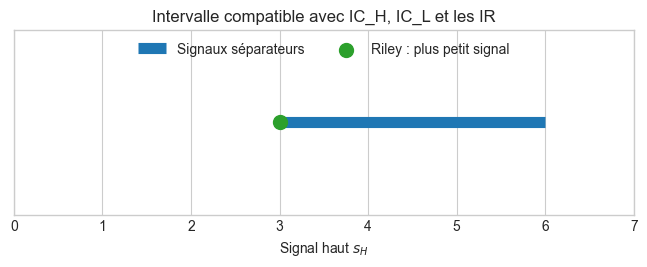

,option_exterieure_H,signal_low,signal_high_lower,signal_high_upper,riley_signal_high,intervalle
0,0.0,0.0,3.0,6.0,3.0,NaN
1,3.0,0.0,3.0,4.0,3.0,NaN
2,4.0,NaN,NaN,NaN,NaN,vide


In [6]:
def spence_separating_interval(
    y_low: float,
    y_high: float,
    q_low: float,
    q_high: float,
    reserve_low: float = 0.0,
    reserve_high: float = 0.0,
) -> dict[str, float] | None:
    """Calcule l’intervalle séparateur pour c(q,s)=s/q et s_low=0."""
    if not y_low < y_high:
        raise ValueError("Le modèle suppose y_low < y_high")
    if not 0.0 < q_low < q_high:
        raise ValueError("Le modèle suppose 0 < q_low < q_high")
    if y_low < reserve_low:
        return None

    productivity_gap = y_high - y_low
    lower = max(0.0, q_low * productivity_gap)
    upper = min(q_high * productivity_gap, q_high * (y_high - reserve_high))
    if lower > upper and not isclose(lower, upper):
        return None
    return {
        "signal_low": 0.0,
        "signal_high_lower": lower,
        "signal_high_upper": upper,
        "riley_signal_high": lower,
    }


spence_rows = []
for reserve_high in (0.0, 3.0, 4.0):
    interval = spence_separating_interval(2, 5, 1, 2, reserve_low=1, reserve_high=reserve_high)
    spence_rows.append({"option_exterieure_H": reserve_high, **(interval or {"intervalle": "vide"})})
spence_results = pd.DataFrame(spence_rows)

interval = spence_separating_interval(2, 5, 1, 2, reserve_low=1, reserve_high=0)
assert interval is not None
fig, ax = plt.subplots(figsize=(8, 2.4))
lower = interval["signal_high_lower"]
upper = interval["signal_high_upper"]
ax.hlines(1, lower, upper, linewidth=8, color="tab:blue", label="Signaux séparateurs")
ax.scatter([lower], [1], color="tab:green", s=100, zorder=3, label="Riley : plus petit signal")
ax.set_xlim(0, upper + 1)
ax.set_ylim(0.5, 1.5)
ax.set_yticks([])
ax.set_xlabel(r"Signal haut $s_H$")
ax.set_title("Intervalle compatible avec IC_H, IC_L et les IR")
ax.legend(loc="upper center", ncol=2)
plt.show()
spence_results

### Lecture du résultat

Sans IR contraignante, l’intervalle séparateur vaut $[3,6]$ et Riley sélectionne sa borne basse $s_H=3$. Une option extérieure plus élevée du type haut réduit la borne supérieure ; à $\bar u_H=4$, l’intervalle devient vide. Ces valeurs sont celles du modèle numérique affiché ci-dessus.

### Exercices 4 et 5 — Spence

**Exercice 4.** Compléter la fonction pour faire varier l’option extérieure du type haut et retourner les bornes de l’intervalle séparateur.  
**Indice :** appeler `spence_separating_interval` pour chaque valeur de `reserve_high`.

**Exercice 5.** Vérifier numériquement les quatre contraintes IC/IR pour un signal haut candidat.  
**Indice :** calculer séparément les utilités des deux types sous vérité et imitation.

In [7]:
def exercice_option_exterieure_spence() -> pd.DataFrame | None:
    # TODO étudiant : faire varier reserve_high et collecter les intervalles.
    return None


def exercice_verifier_ic_ir(signal_high: float) -> dict[str, bool] | None:
    # TODO étudiant : évaluer séparément IC_H, IC_L, IR_H et IR_L.
    return None


print(
    "Exercices Spence à compléter :",
    exercice_option_exterieure_spence(),
    exercice_verifier_ic_ir(3.0),
)

Exercices Spence à compléter : None None


## Rothschild–Stiglitz : screening concurrentiel fini

Un contrat $C=(\alpha,\beta)$ fixe une couverture $\alpha\in[0,1]$ et une prime $\beta$. La convention est explicite : $p_H>p_L$, donc `H` est le haut risque. Avec une perte $D$, le profit attendu de l’assureur pour un type $p$ est

$$\Pi(C,p)=\beta-p\alpha D.$$

La frontière actuariellement équitable est définie **type par type** par $\beta=p\alpha D$. Elle ne constitue pas une subvention croisée. Dans le concept de Rothschild–Stiglitz, un menu candidat est un Nash entre assureurs seulement si aucune déviation unilatérale n’attire un sous-ensemble de types avec profit conditionnel positif. La non-existence est donc conditionnelle à une déviation cream-skimming effectivement trouvée sur la grille finie.

Déviations profitables : 319 ; cream-skimming L seul : 176


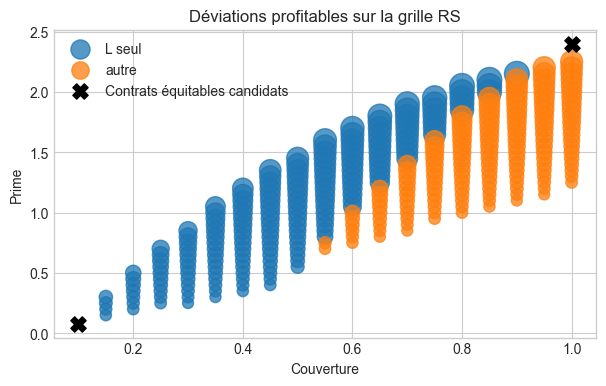

,couverture,prime,attire_L,attire_H,profit_conditionnel
0,0.15,0.15,True,False,0.03
1,0.15,0.20,True,False,0.08
2,0.15,0.25,True,False,0.13
3,0.15,0.30,True,False,0.18
4,0.20,0.20,True,False,0.04
5,0.20,0.25,True,False,0.09
6,0.20,0.30,True,False,0.14
7,0.20,0.35,True,False,0.19
8,0.20,0.40,True,False,0.24
9,0.20,0.45,True,False,0.29


In [8]:
@dataclass(frozen=True)
class Contract:
    coverage: float
    premium: float


def expected_utility(
    contract: Contract,
    loss_probability: float,
    wealth: float = 10.0,
    loss: float = 8.0,
    risk_aversion: float = 0.35,
) -> float:
    """Calcule l’utilité CARA espérée d’un type assuré."""
    if not 0.0 <= loss_probability <= 1.0:
        raise ValueError("loss_probability doit appartenir à [0, 1]")
    if not 0.0 <= contract.coverage <= 1.0:
        raise ValueError("coverage doit appartenir à [0, 1]")
    wealth_no_loss = wealth - contract.premium
    wealth_with_loss = wealth - contract.premium - (1.0 - contract.coverage) * loss
    utility = lambda value: -exp(-risk_aversion * value)
    return (
        (1.0 - loss_probability) * utility(wealth_no_loss)
        + loss_probability * utility(wealth_with_loss)
    )


def expected_profit(contract: Contract, loss_probability: float, loss: float = 8.0) -> float:
    """Calcule le profit attendu de l’assureur pour un type."""
    return contract.premium - loss_probability * contract.coverage * loss


def chosen_contract(menu: tuple[Contract, ...], loss_probability: float) -> Contract:
    """Retourne le contrat préféré, option extérieure comprise."""
    outside = Contract(coverage=0.0, premium=0.0)
    return max((outside, *menu), key=lambda contract: expected_utility(contract, loss_probability))


def menu_outcome(
    menu: tuple[Contract, ...], pi_high: float, p_low: float, p_high: float
) -> dict[str, object]:
    """Évalue les choix et le profit agrégé d’un menu à deux types."""
    if not 0.0 <= pi_high <= 1.0:
        raise ValueError("pi_high doit appartenir à [0, 1]")
    if not 0.0 < p_low < p_high < 1.0:
        raise ValueError("Le modèle suppose 0 < p_low < p_high < 1")
    low_choice = chosen_contract(menu, p_low)
    high_choice = chosen_contract(menu, p_high)
    low_profit = expected_profit(low_choice, p_low)
    high_profit = expected_profit(high_choice, p_high)
    return {
        "low_choice": low_choice,
        "high_choice": high_choice,
        "low_profit": low_profit,
        "high_profit": high_profit,
        "aggregate_profit": (1.0 - pi_high) * low_profit + pi_high * high_profit,
        "cross_subsidy": low_profit * high_profit < 0.0,
    }


def rs_profitable_deviations(
    incumbent_menu: tuple[Contract, ...],
    candidate_contracts: tuple[Contract, ...],
    pi_high: float,
    p_low: float,
    p_high: float,
    tolerance: float = 1e-9,
) -> list[dict[str, object]]:
    """Énumère les déviations profitables sur les types qu’elles attirent."""
    incumbent = menu_outcome(incumbent_menu, pi_high, p_low, p_high)
    incumbent_low_u = expected_utility(incumbent["low_choice"], p_low)
    incumbent_high_u = expected_utility(incumbent["high_choice"], p_high)
    deviations: list[dict[str, object]] = []

    for contract in candidate_contracts:
        attracts_low = expected_utility(contract, p_low) > incumbent_low_u + tolerance
        attracts_high = expected_utility(contract, p_high) > incumbent_high_u + tolerance
        mass = (1.0 - pi_high) * attracts_low + pi_high * attracts_high
        if mass <= 0.0:
            continue
        weighted_profit = (
            (1.0 - pi_high) * attracts_low * expected_profit(contract, p_low)
            + pi_high * attracts_high * expected_profit(contract, p_high)
        )
        conditional_profit = weighted_profit / mass
        if conditional_profit > tolerance:
            deviations.append({
                "contract": contract,
                "attracts_low": attracts_low,
                "attracts_high": attracts_high,
                "conditional_profit": conditional_profit,
            })
    return deviations


p_low, p_high, pi_high = 0.10, 0.30, 0.25
fair_low = Contract(coverage=0.10, premium=p_low * 0.10 * 8.0)
fair_high = Contract(coverage=1.00, premium=p_high * 1.00 * 8.0)
assert isclose(expected_profit(fair_low, p_low), 0.0)
assert isclose(expected_profit(fair_high, p_high), 0.0)
contract_grid = tuple(
    Contract(coverage=coverage, premium=premium)
    for coverage in np.linspace(0.05, 1.00, 20)
    for premium in np.linspace(0.05, 3.20, 64)
)
deviations = rs_profitable_deviations(
    (fair_low, fair_high), contract_grid, pi_high, p_low, p_high
)
assert deviations, "La grille doit exhiber une déviation profitable."
deviation_frame = pd.DataFrame([
    {
        "couverture": item["contract"].coverage,
        "prime": item["contract"].premium,
        "attire_L": item["attracts_low"],
        "attire_H": item["attracts_high"],
        "profit_conditionnel": item["conditional_profit"],
    }
    for item in deviations
])
print(
    f"Déviations profitables : {len(deviation_frame)} ; "
    f"cream-skimming L seul : {(deviation_frame['attire_L'] & ~deviation_frame['attire_H']).sum()}"
)
fig, ax = plt.subplots(figsize=(7, 4))
dev_frame = pd.DataFrame([
    {
        "coverage": item["contract"].coverage,
        "premium": item["contract"].premium,
        "profit": item["conditional_profit"],
        "target": "L seul" if item["attracts_low"] and not item["attracts_high"] else "autre",
    }
    for item in deviations
])
for target, group in dev_frame.groupby("target"):
    ax.scatter(
        group["coverage"],
        group["premium"],
        s=60 + 180 * group["profit"],
        label=target,
        alpha=0.75,
    )
ax.scatter(
    [fair_low.coverage, fair_high.coverage],
    [fair_low.premium, fair_high.premium],
    marker="X",
    s=120,
    color="black",
    label="Contrats équitables candidats",
)
ax.set(xlabel="Couverture", ylabel="Prime", title="Déviations profitables sur la grille RS")
ax.legend()
plt.show()
deviation_frame.head(10)

### Lecture du résultat

Les deux croix sont break-even pour leur type respectif, mais cela ne suffit pas à former un Nash. La grille affiche des déviations rentables, dont certaines attirent uniquement le bas risque : c’est le mécanisme de cream-skimming qui rend ici la non-existence RS conditionnellement visible. Le résultat vaut pour cette grille, ces utilités et cette convention de risque.

### Exercices 6 et 7 — Rothschild–Stiglitz

**Exercice 6.** Construire la frontière actuariellement équitable pour chaque type et vérifier le profit nul type par type.  
**Exercice 7.** Filtrer `deviation_frame` pour isoler les déviations qui attirent uniquement `L`, puis classer les cinq plus profitables.

Les deux exercices gardent distincts le break-even RS et une éventuelle subvention croisée au niveau d’un menu anticipatif.

In [9]:
def exercice_frontieres_equitables() -> pd.DataFrame | None:
    # TODO étudiant : générer les primes break-even pour p_low et p_high.
    return None


def exercice_cream_skimming() -> pd.DataFrame | None:
    # TODO étudiant : filtrer puis trier les déviations qui attirent L seul.
    return None


print(
    "Exercices RS à compléter :",
    exercice_frontieres_equitables(),
    exercice_cream_skimming(),
)

Exercices RS à compléter : None None


## Wilson / Miyazaki / Spence : règle anticipative bornée

Nous fixons maintenant une définition computationnelle complète, sans lui attribuer une portée générale :

1. l’ensemble admissible est une grille finie de contrats ;
2. chaque type choisit son utilité CARA maximale, option extérieure comprise ;
3. le profit d’un menu est la moyenne pondérée des profits sur les contrats choisis ;
4. après l’entrée d’un nouveau contrat, tout contrat **incumbent choisi mais déficitaire** est retiré ;
5. les choix sont recalculés jusqu’au point fixe de retrait ;
6. une déviation est profitable si le profit final de l’entrant est positif ;
7. un menu est retenu s’il est faisable en profit agrégé et n’admet aucune telle déviation sur la grille.

Une subvention croisée est possible au niveau du menu lorsqu’un type génère un profit positif et l’autre un profit négatif, avec profit agrégé non négatif. L’énumération peut produire zéro, un ou plusieurs menus ; aucun résultat d’existence ou d’unicité n’est supposé.

Menus anticipatifs retenus : 9 sur une grille finie de 12 contrats


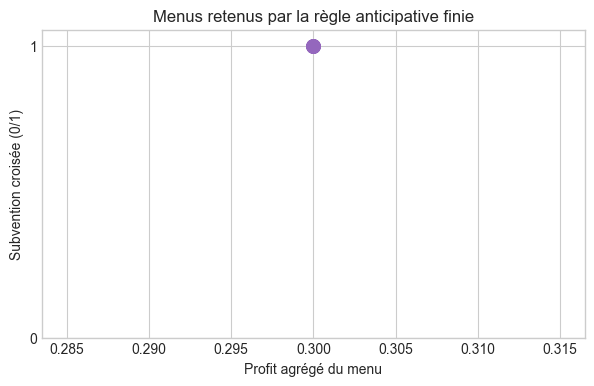

,menu,choix_L,choix_H,profit_agrege,subvention_croisee
0,"[(0.75, 1.2)]","(0.75, 1.2)","(0.75, 1.2)",0.3,True
1,"[(0.25, 0.4), (0.75, 1.2)]","(0.75, 1.2)","(0.75, 1.2)",0.3,True
2,"[(0.25, 0.8), (0.75, 1.2)]","(0.75, 1.2)","(0.75, 1.2)",0.3,True
3,"[(0.25, 1.2), (0.75, 1.2)]","(0.75, 1.2)","(0.75, 1.2)",0.3,True
4,"[(0.25, 1.6), (0.75, 1.2)]","(0.75, 1.2)","(0.75, 1.2)",0.3,True
5,"[(0.5, 0.8), (0.75, 1.2)]","(0.75, 1.2)","(0.75, 1.2)",0.3,True
6,"[(0.5, 1.2), (0.75, 1.2)]","(0.75, 1.2)","(0.75, 1.2)",0.3,True
7,"[(0.5, 1.6), (0.75, 1.2)]","(0.75, 1.2)","(0.75, 1.2)",0.3,True
8,"[(0.75, 1.2), (0.75, 1.6)]","(0.75, 1.2)","(0.75, 1.2)",0.3,True


In [10]:
def anticipatory_deviation(
    incumbent_menu: tuple[Contract, ...],
    entrant: Contract,
    pi_high: float,
    p_low: float,
    p_high: float,
    tolerance: float = 1e-9,
) -> dict[str, object]:
    """Applique le point fixe fini de retrait à une déviation."""
    active_incumbents = list(incumbent_menu)
    withdrawn: list[Contract] = []
    type_data = ((1.0 - pi_high, p_low), (pi_high, p_high))

    while True:
        available = tuple(active_incumbents) + (entrant,)
        choices = [chosen_contract(available, probability) for _, probability in type_data]
        newly_withdrawn = []
        for contract in active_incumbents:
            contract_profit = sum(
                mass * expected_profit(contract, probability)
                for (mass, probability), choice in zip(type_data, choices)
                if choice == contract
            )
            if contract in choices and contract_profit < -tolerance:
                newly_withdrawn.append(contract)
        if not newly_withdrawn:
            break
        withdrawn.extend(newly_withdrawn)
        active_incumbents = [
            contract for contract in active_incumbents if contract not in newly_withdrawn
        ]

    final_menu = tuple(active_incumbents) + (entrant,)
    final_choices = [chosen_contract(final_menu, probability) for _, probability in type_data]
    entrant_profit = sum(
        mass * expected_profit(entrant, probability)
        for (mass, probability), choice in zip(type_data, final_choices)
        if choice == entrant
    )
    return {
        "entrant": entrant,
        "withdrawn": tuple(withdrawn),
        "final_choices": tuple(final_choices),
        "entrant_profit": entrant_profit,
        "profitable": entrant_profit > tolerance,
    }


def anticipatory_menus(
    contracts: tuple[Contract, ...],
    pi_high: float,
    p_low: float,
    p_high: float,
    max_menu_size: int = 2,
    tolerance: float = 1e-9,
) -> list[dict[str, object]]:
    """Énumère les menus stables sous la règle finie documentée."""
    retained: list[dict[str, object]] = []
    for size in range(1, max_menu_size + 1):
        for menu in combinations(contracts, size):
            outcome = menu_outcome(menu, pi_high, p_low, p_high)
            if outcome["aggregate_profit"] < -tolerance:
                continue
            reactions = [
                anticipatory_deviation(menu, entrant, pi_high, p_low, p_high, tolerance)
                for entrant in contracts
                if entrant not in menu
            ]
            if not any(reaction["profitable"] for reaction in reactions):
                retained.append({"menu": menu, "reactions": reactions, **outcome})
    return retained


small_grid = tuple(
    Contract(coverage=coverage, premium=premium)
    for coverage in (0.25, 0.50, 0.75)
    for premium in (0.4, 0.8, 1.2, 1.6)
)
menus = anticipatory_menus(small_grid, pi_high, p_low, p_high)
menu_summary = pd.DataFrame([
    {
        "menu": [(c.coverage, c.premium) for c in item["menu"]],
        "choix_L": (item["low_choice"].coverage, item["low_choice"].premium),
        "choix_H": (item["high_choice"].coverage, item["high_choice"].premium),
        "profit_agrege": item["aggregate_profit"],
        "subvention_croisee": item["cross_subsidy"],
    }
    for item in menus
])
print(
    f"Menus anticipatifs retenus : {len(menu_summary)} "
    f"sur une grille finie de {len(small_grid)} contrats"
)

fig, ax = plt.subplots(figsize=(7, 4))
if not menu_summary.empty:
    ax.scatter(
        menu_summary["profit_agrege"],
        menu_summary["subvention_croisee"].astype(int),
        s=90,
        alpha=0.75,
        color="tab:purple",
    )
ax.set(
    xlabel="Profit agrégé du menu",
    ylabel="Subvention croisée (0/1)",
    yticks=[0, 1],
    title="Menus retenus par la règle anticipative finie",
)
plt.show()
menu_summary.head(10)

### Lecture du résultat

La grille finie retient le nombre de menus imprimé par la cellule précédente ; certains peuvent porter une subvention croisée tout en gardant un profit agrégé non négatif. Cette observation n’est ni une preuve d’existence générale ni une preuve d’unicité : elle dépend de la grille, de l’utilité CARA et de la règle itérative de retrait définies ici.

### Lien vers l’IA et la décision automatisée

Un modèle apprenant sous labels bruités rencontre une information imparfaite, mais il n’est pas automatiquement un marché d’Akerlof. En revanche, la conception automatisée de mécanismes peut rechercher un menu satisfaisant IC, IR et faisabilité. Les jeux bayésiens de Harsanyi fournissent alors le langage commun : types privés, croyances et stratégies contingentes au type.

### Exercices 8 et 9 — règle anticipative

**Exercice 8.** Modifier une prime du `small_grid` et mesurer quels incumbents sont retirés après l’entrée d’un contrat donné.  
**Exercice 9.** Faire varier `pi_high` et compter les menus retenus ainsi que ceux qui portent une subvention croisée.

Chaque exercice doit rapporter zéro, un ou plusieurs menus sans forcer une conclusion d’existence ou d’unicité.

In [11]:
def exercice_retrait_incumbents() -> dict[str, object] | None:
    # TODO étudiant : appeler anticipatory_deviation et examiner withdrawn.
    return None


def exercice_part_haut_risque() -> pd.DataFrame | None:
    # TODO étudiant : faire varier pi_high et compter les menus retenus.
    return None


print(
    "Exercices anticipatifs à compléter :",
    exercice_retrait_incumbents(),
    exercice_part_haut_risque(),
)

Exercices anticipatifs à compléter : None None


## Synthèse comparative

| Concept | Initiative | Hypothèses codées | Résultat analytique | Résultat numérique |
|---|---|---|---|---|
| Akerlof | Prix unique du marché | Deux qualités, point fixe de participation | Seuil de possibilité du pooling | Multiplicité et no-trade selon les paramètres |
| Spence | Signal de l’agent informé | Deux types, $c(q,s)=s/q$, IC et IR | Intervalle séparateur et borne de Riley | Intervalle vide ou non selon l’option extérieure |
| Rothschild–Stiglitz | Menu concurrentiel d’assureurs | Deux risques, CARA, grille finie | Break-even type par type | Déviations cream-skimming explicitement calculées |
| Wilson/MWS | Réaction anticipative à une déviation | Grille et retrait itératif finis | Définition bornée, pas de théorème général | Zéro, un ou plusieurs menus avec/sans subvention croisée |

## Conclusion

Les quatre modèles partagent des types privés, mais ils ne déplacent pas l’information de la même façon : Akerlof étudie la sélection induite par un prix, Spence un signal coûteux, RS un screening concurrentiel et Wilson/MWS une réaction anticipative des contrats incumbents. Les sorties exécutées restent attachées aux hypothèses finies énoncées ; elles ne fabriquent aucune existence ou unicité générale.